In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [ ]:
import os
print (os.listdir())

['.config', 'insurance.csv', 'sample_data']


In [ ]:
df = pd.read_csv("insurance.csv")

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.shape

(1338, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

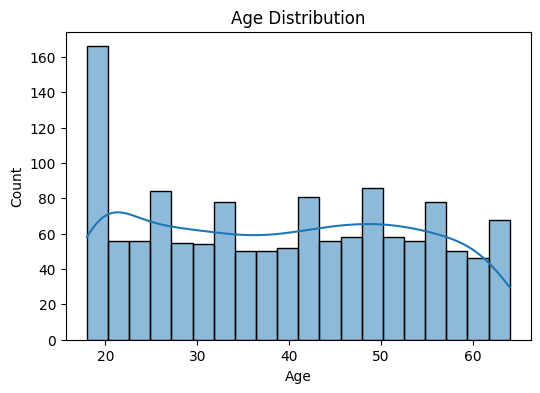

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

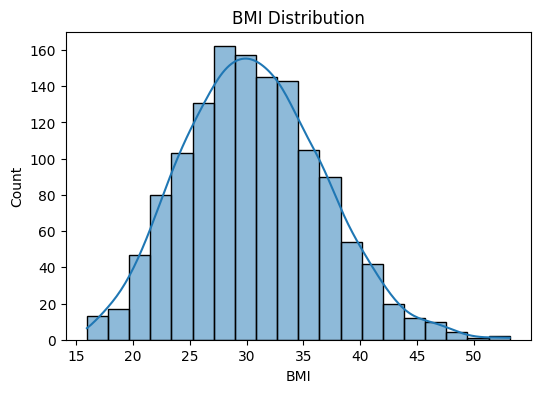

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["bmi"], bins=20, kde=True)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()

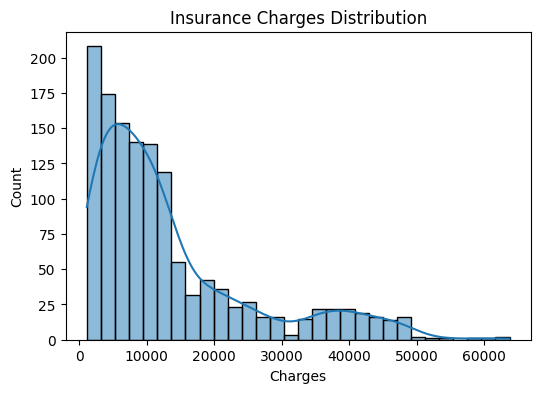

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["charges"], bins=30, kde=True)
plt.title("Insurance Charges Distribution")
plt.xlabel("Charges")
plt.ylabel("Count")
plt.show()

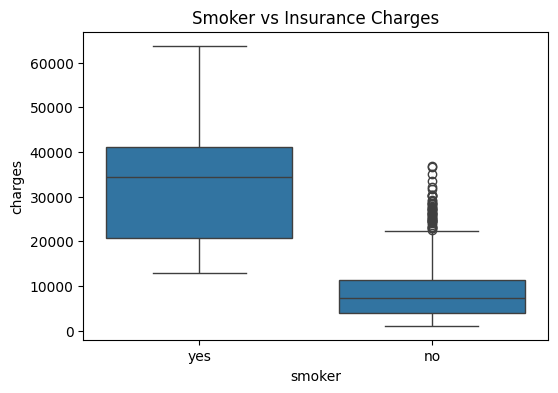

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="smoker", y="charges", data=df)
plt.title("Smoker vs Insurance Charges")
plt.show()

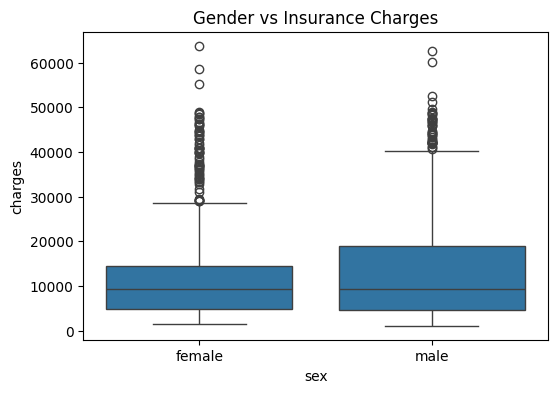

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="sex", y="charges", data=df)
plt.title("Gender vs Insurance Charges")
plt.show()

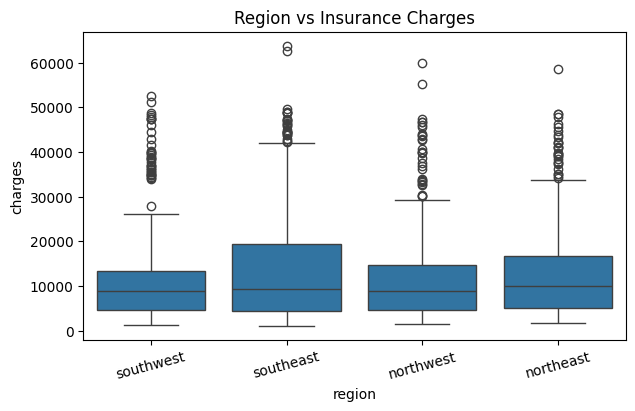

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(x="region", y="charges", data=df)
plt.title("Region vs Insurance Charges")
plt.xticks(rotation=15)
plt.show()

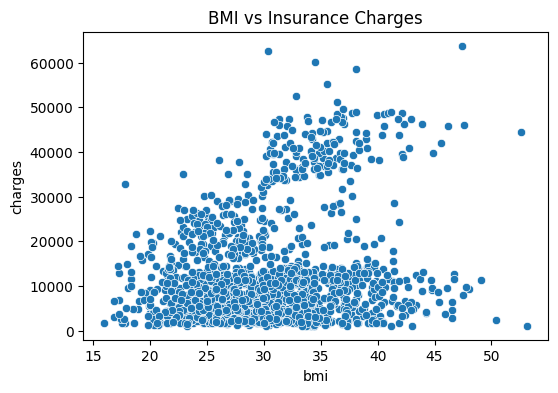

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="bmi", y="charges", data=df)
plt.title("BMI vs Insurance Charges")
plt.show()

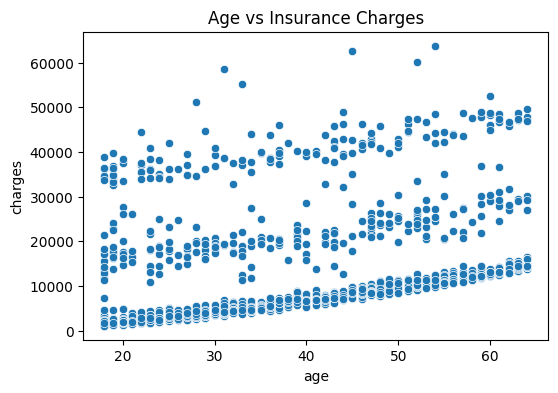

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="age", y="charges", data=df)
plt.title("Age vs Insurance Charges")
plt.show()

In [ ]:
encoder = LabelEncoder()
for column in df.select_dtypes(include="object").columns:
    df[column] = encoder.fit_transform(df[column])
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [ ]:
encoders = {}
for column in df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    encoders[column] = le
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [ ]:
print("Sex Encoding")
print(df["sex"].value_counts().sort_index())
print()
print("Smoker Encoding")
print(df["smoker"].value_counts().sort_index())
print()
print("Region Encoding")
print(df["region"].value_counts().sort_index())

Sex Encoding
sex
0    662
1    676
Name: count, dtype: int64

Smoker Encoding
smoker
0    1064
1     274
Name: count, dtype: int64

Region Encoding
region
0    324
1    325
2    364
3    325
Name: count, dtype: int64


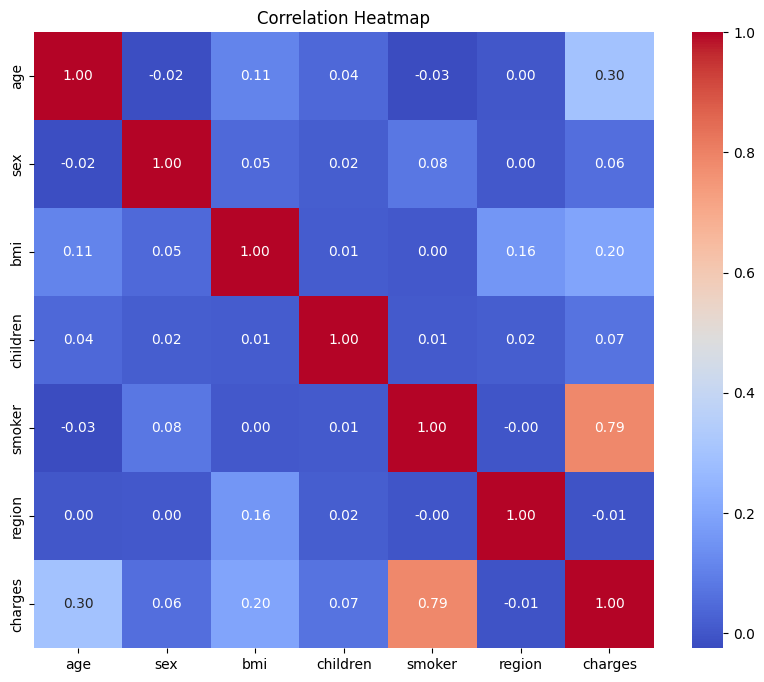

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
X = df.drop("charges", axis=1)
y = df["charges"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score :", r2_score(y_test, y_pred))

MAE : 4186.508898366436
MSE : 33635210.43117845
RMSE : 5799.5870914383595
R² Score : 0.7833463107364536


In [ ]:
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})
result.head(10)

,Actual,Predicted
0,9095.06825,8924.407244
1,5272.17580,7116.295018
2,29330.98315,36909.013521
3,9301.89355,9507.874691
4,33750.29180,27013.350008
5,4536.25900,10790.779562
6,2117.33885,226.298446
7,14210.53595,16942.715999
8,3732.62510,1056.630794
9,10264.44210,11267.919973


In [ ]:
print("MAE :", mean_absolute_error(result["Actual"], result["Predicted"]))
print("MSE :", mean_squared_error(result["Actual"], result["Predicted"]))
print("RMSE :", np.sqrt(mean_squared_error(result["Actual"], result["Predicted"])))
print("R² Score :", r2_score(result["Actual"], result["Predicted"]))

MAE : 4186.508898366436
MSE : 33635210.43117845
RMSE : 5799.5870914383595
R² Score : 0.7833463107364536


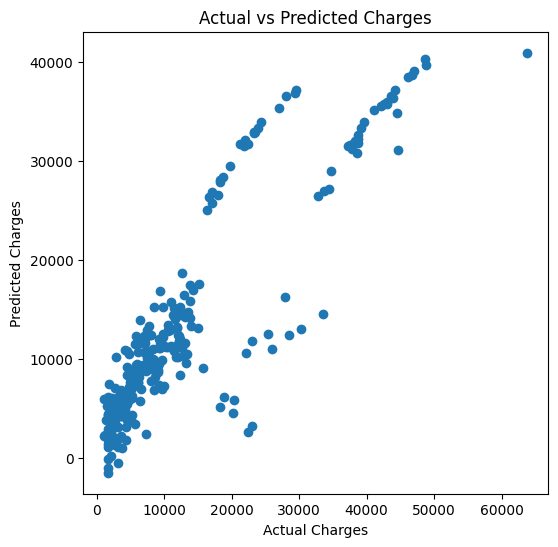

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.show()

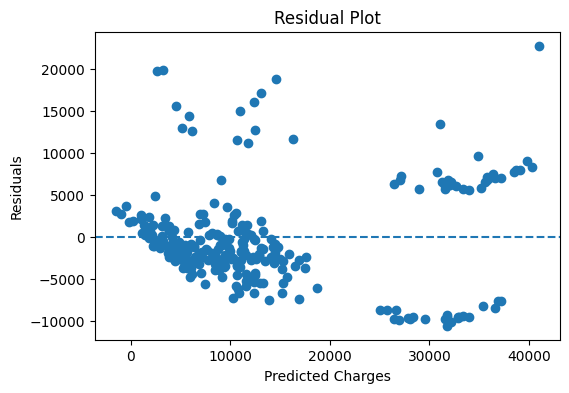

In [ ]:
residuals = y_test - y_pred
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [ ]:
joblib.dump(model, "insurance_model.pkl")
joblib.dump(scaler, "insurance_scaler.pkl")

['insurance_scaler.pkl']

In [ ]:
from google.colab import files
files.download("insurance_model.pkl")
files.download("insurance_scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import ipywidgets as widgets
from IPython.display import display

In [ ]:
age = widgets.IntSlider(min=18, max=64, value=25, description="Age")
sex = widgets.Dropdown(
    options=["female", "male"],
    description="Sex"
)
bmi = widgets.FloatText(
    value=25.0,
    description="BMI"
)
children = widgets.IntSlider(
    min=0,
    max=5,
    value=0,
    description="Children"
)
smoker = widgets.Dropdown(
    options=["no", "yes"],
    description="Smoker"
)
region = widgets.Dropdown(
    options=["southwest", "southeast", "northwest", "northeast"],
    description="Region"
)

button = widgets.Button(
    description="Predict Charges",
    button_style="success"
)
output = widgets.Output()

clear_output_button = widgets.Button(
    description="Clear Output",
    button_style="info"
)
reset_inputs_button = widgets.Button(
    description="Reset Inputs",
    button_style="warning"
)

In [1]:
def on_clear_output_button_click(b):
    output.clear_output()

def on_reset_inputs_button_click(b):
    age.value = 25
    sex.value = "female"
    bmi.value = 25.0
    children.value = 0
    smoker.value = "no"
    region.value = "southwest"
    output.clear_output()

clear_output_button.on_click(on_clear_output_button_click)
reset_inputs_button.on_click(on_reset_inputs_button_click)

region_map = {
    "northeast": 0,
    "northwest": 1,
    "southeast": 2,
    "southwest": 3
}

def get_input_data(age_val, sex_val, bmi_val, children_val, smoker_val, region_val):
    sex_encoded = 1 if sex_val == "male" else 0
    smoker_encoded = 1 if smoker_val == "yes" else 0
    region_encoded = region_map[region_val]

    data = [[
        age_val,
        sex_encoded,
        bmi_val,
        children_val,
        smoker_encoded,
        region_encoded
    ]]

    return scaler.transform(data)

def predict(b):
    output.clear_output()

    if not (18 <= age.value <= 64):
        with output:
            print("Age must be between 18 and 64.")
        return

    if not (10 <= bmi.value <= 60):
        with output:
            print("BMI must be between 10 and 60.")
        return

    data = get_input_data(
        age.value,
        sex.value,
        bmi.value,
        children.value,
        smoker.value,
        region.value
    )

    prediction = model.predict(data)[0]

    with output:
        print("=" * 45)
        print("      INSURANCE COST PREDICTION")
        print("=" * 45)
        print(f"Estimated Annual Charges : ${prediction:,.2f}")

button.on_click(predict)

# Organize widgets for display
display(
    widgets.VBox([
        widgets.HBox([age, sex]),
        widgets.HBox([bmi, children]),
        widgets.HBox([smoker, region]),
        widgets.HBox([button, clear_output_button, reset_inputs_button]),
        output # For the text prediction output
    ])
)

NameError: name 'clear_output_button' is not defined